In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python:", sys.executable)
print("Pandas:", pd.__version__)
print("Kernel funcionando correctamente")

Python: /home/ricardo/miniconda/envs/unet-gpu/bin/python
Pandas: 2.3.3
Kernel funcionando correctamente


In [3]:
from pathlib import Path

print("Directorio actual:", Path.cwd())

Directorio actual: /home/ricardo/Tesis 2/tesis-flujo-caja-ia


In [1]:
from pathlib import Path

print("Directorio de ejecución:", Path.cwd())

print(
    "Archivo desde raíz:",
    Path("data/processed/panel_fcl_preliminar.csv").exists()
)

print(
    "Archivo desde notebooks:",
    Path("../data/processed/panel_fcl_preliminar.csv").exists()
)

Directorio de ejecución: /home/ricardo/Tesis 2/tesis-flujo-caja-ia/notebooks
Archivo desde raíz: False
Archivo desde notebooks: True


In [2]:
import pandas as pd
from pathlib import Path

# Ruta de la base de datos desde la carpeta notebooks
ruta = Path("../data/processed/panel_fcl_preliminar.csv")

print("Archivo encontrado:", ruta.exists())

# Cargar la base financiera
df = pd.read_csv(
    ruta,
    dtype={"RPJ": str, "RUC": str}
)

print("\nANÁLISIS EXPLORATORIO DE DATOS - TESIS UNI")
print("=" * 55)

print("Observaciones:", len(df))
print("Empresas:", df["RPJ"].nunique())
print("Años:", df["Ejercicio"].nunique())
print("Variables:", len(df.columns))

display(df.head(10))

Archivo encontrado: True

ANÁLISIS EXPLORATORIO DE DATOS - TESIS UNI
Observaciones: 4221
Empresas: 336
Años: 21
Variables: 23


,RPJ,RUC,NombreEmpresa,Ejercicio,TipoEmpresa,TipoSector,CIIU,TipoInformacion,Trimestre,Moneda,...,PatrimonioTotal,TotalIngreso,UtilidadNeta,FCO,CAPEX_reportado,FCL_preliminar,codigo_FCO,codigo_CAPEX,revision_interanual,estado_FCL
0,B30150,20100022142,ABB S.A.,2005,EMPRESAS EMISORAS,INDUSTRIALES,NaN,Anual Individual,Anual,Soles,...,36442,112082,1338,6113.0,-924.0,5189.0,3D01ST,3D0206,False,PRELIMINAR
1,020045,20260172035,ACTIVO INMOBILIARIO PERUANO S.A.A. (ANTES FALA...,2005,EMPRESAS EMISORAS,DIVERSOS,NaN,Anual Individual,Anual,Soles,...,465014,11649,105017,69166.0,0.0,69166.0,3D01ST,3D0206,False,PRELIMINAR
2,B80018,20100047307,ADMINISTRADORA DEL COMERCIO S.A. EN LIQUIDACION,2005,EMPRESAS EMISORAS,DIVERSOS,NaN,Anual Individual,Anual,Soles,...,35123,1896,-19400,2281.0,-127.0,2154.0,3D01ST,3D0206,True,PRELIMINAR
3,023106,20332600592,AENZA S.A.A.,2005,EMPRESAS EMISORAS,DIVERSOS,NaN,Anual Individual,Anual,Soles,...,238945,9137,32724,22565.0,0.0,22565.0,3D01ST,3D0206,False,PRELIMINAR
4,AFP005,20143980821,AFP HORIZONTE S.A.,2005,EMPRESAS EMISORAS,A.F.P.,NaN,Anual Individual,Anual,Soles,...,131862,163205,76517,63690.0,-1210.0,62480.0,3D01ST,3D0206,False,PRELIMINAR
5,AFP002,20157036794,AFP INTEGRA,2005,EMPRESAS EMISORAS,A.F.P.,NaN,Anual Individual,Anual,Soles,...,156466,179063,72398,39094.0,-3183.0,35911.0,3D01ST,3D0206,False,PRELIMINAR
6,AFP008,20170124449,AFP UNION VIDA S A,2005,EMPRESAS EMISORAS,A.F.P.,NaN,Anual Individual,Anual,Soles,...,135031,162412,71758,70671.0,-1252.0,69419.0,3D01ST,3D0206,False,PRELIMINAR
7,B11073,20164042686,AGRICOLA CAYALTI SOCIEDAD ANONIMA ABIERTA,2005,EMPRESAS EMISORAS,AGRICOLAS,NaN,Anual Individual,Anual,Soles,...,11559,8370,9184,0.0,0.0,0.0,3D01ST,3D0206,False,PRELIMINAR
8,B11067,20135948641,AGRO INDUSTRIAL PARAMONGA S.A.,2005,EMPRESAS EMISORAS,AGRICOLAS,NaN,Anual Individual,Anual,Soles,...,234503,166734,9155,9513.0,-19352.0,-9839.0,3D01ST,3D0206,True,PRELIMINAR
9,B08363,20132377783,AGROINDUSTRIAL LAREDO S.A.A.,2005,EMPRESAS EMISORAS,AGRICOLAS,NaN,Anual Individual,Anual,Soles,...,243141,146091,33780,22038.0,-20225.0,1813.0,3D01ST,3D0206,True,PRELIMINAR


In [5]:
# ==========================================
# EDA - 2. CALIDAD DE LOS DATOS
# ==========================================

import pandas as pd

print("=" * 60)
print("ANÁLISIS DE CALIDAD DE DATOS")
print("=" * 60)

# 1. Dimensiones
print("\nDimensiones:", df.shape)

# 2. Tipos de datos
print("\nTIPOS DE VARIABLES")
print(df.dtypes.to_string())

# 3. Valores faltantes
faltantes = pd.DataFrame({
    "Valores faltantes": df.isna().sum(),
    "Porcentaje (%)": (df.isna().mean() * 100).round(2)
})

faltantes = faltantes.sort_values(
    "Porcentaje (%)", ascending=False
)

print("\nVALORES FALTANTES")
display(faltantes)

# 4. Duplicados por empresa y año
duplicados = df.duplicated(
    subset=["RPJ", "Ejercicio"]
).sum()

print("\nDuplicados empresa-año:", duplicados)

# 5. Estados del FCL
print("\nESTADO DE LOS REGISTROS DEL FCL")
display(
    df["estado_FCL"]
    .value_counts(dropna=False)
    .to_frame(name="Observaciones")
)

# 6. Registros completos e incompletos
print("\nRESUMEN DE CALIDAD")
print("Empresas únicas:", df["RPJ"].nunique())
print("Años disponibles:", df["Ejercicio"].nunique())
print("Observaciones totales:", len(df))
print("Observaciones con FCL:", df["FCL_preliminar"].notna().sum())

ANÁLISIS DE CALIDAD DE DATOS

Dimensiones: (4221, 23)

TIPOS DE VARIABLES
RPJ                     object
RUC                     object
NombreEmpresa           object
Ejercicio                int64
TipoEmpresa             object
TipoSector              object
CIIU                   float64
TipoInformacion         object
Trimestre               object
Moneda                  object
MetodoFlujoEfectivo     object
ActivoTotal              int64
PasivoTotal              int64
PatrimonioTotal          int64
TotalIngreso             int64
UtilidadNeta             int64
FCO                    float64
CAPEX_reportado        float64
FCL_preliminar         float64
codigo_FCO              object
codigo_CAPEX            object
revision_interanual       bool
estado_FCL              object

VALORES FALTANTES


,Valores faltantes,Porcentaje (%)
CIIU,3872,91.73
FCL_preliminar,323,7.65
CAPEX_reportado,247,5.85
codigo_CAPEX,247,5.85
FCO,90,2.13
codigo_FCO,90,2.13
RUC,0,0.00
TipoSector,0,0.00
TipoEmpresa,0,0.00
Ejercicio,0,0.00



Duplicados empresa-año: 0

ESTADO DE LOS REGISTROS DEL FCL


,Observaciones
estado_FCL,
PRELIMINAR,3898
INCOMPLETO,301
REVISAR_CAPEX_POSITIVO,22



RESUMEN DE CALIDAD
Empresas únicas: 336
Años disponibles: 21
Observaciones totales: 4221
Observaciones con FCL: 3898


,Ejercicio,Empresas,Registros,FCL_disponibles,Cobertura_FCL_pct
0,2005,194,194,158,81.44
1,2006,189,189,167,88.36
2,2007,202,202,177,87.62
3,2008,207,207,180,86.96
4,2009,212,212,180,84.91
5,2010,213,213,155,72.77
6,2011,216,216,151,69.91
7,2012,221,221,182,82.35
8,2013,217,217,215,99.08
9,2014,215,215,214,99.53


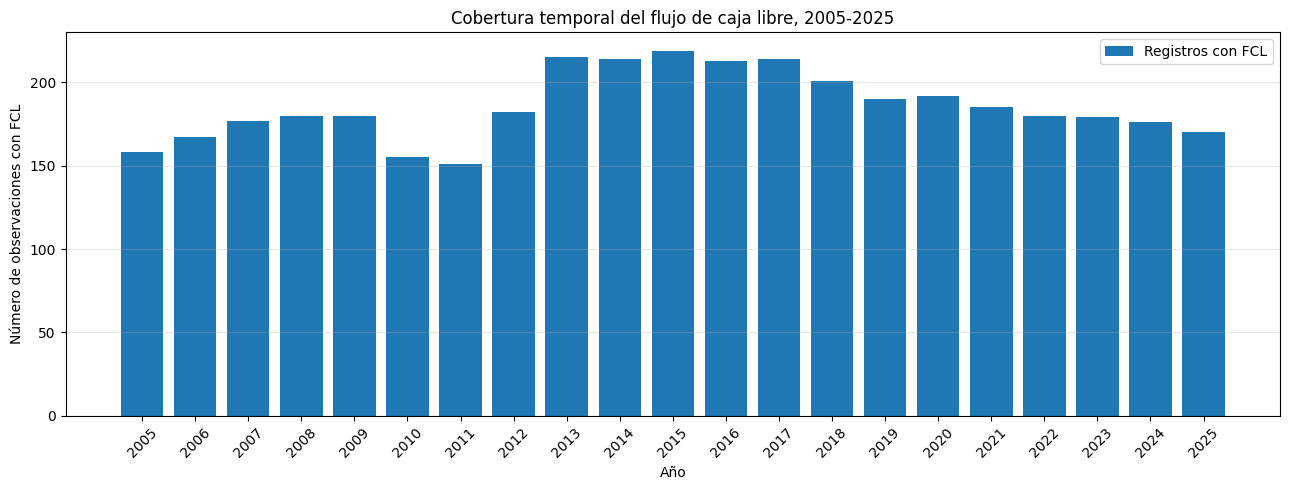

Cobertura global del FCL: 92.35 %


In [6]:
# ==========================================
# EDA - 3. COBERTURA TEMPORAL DEL FCL
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd

# Cobertura anual
cobertura = (
    df.groupby("Ejercicio")
    .agg(
        Empresas=("RPJ", "nunique"),
        Registros=("RPJ", "size"),
        FCL_disponibles=("FCL_preliminar", "count")
    )
    .reset_index()
    .sort_values("Ejercicio")
)

cobertura["Cobertura_FCL_pct"] = (
    cobertura["FCL_disponibles"]
    / cobertura["Registros"] * 100
).round(2)

display(cobertura)

# Gráfico de cobertura
plt.figure(figsize=(13, 5))

plt.bar(
    cobertura["Ejercicio"].astype(str),
    cobertura["FCL_disponibles"],
    label="Registros con FCL"
)

plt.title(
    "Cobertura temporal del flujo de caja libre, 2005-2025"
)
plt.xlabel("Año")
plt.ylabel("Número de observaciones con FCL")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print(
    "Cobertura global del FCL:",
    round(df["FCL_preliminar"].notna().mean() * 100, 2),
    "%"
)

In [7]:
# ==========================================
# EDA - 4. ESTADÍSTICA DESCRIPTIVA DEL FCL
# ==========================================

import pandas as pd
import numpy as np

# Seleccionar observaciones con FCL disponible
df_fcl = df.dropna(subset=["FCL_preliminar"]).copy()

# Estadística descriptiva general
estadisticas = df_fcl["FCL_preliminar"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS DEL FCL")
print("=" * 60)

display(estadisticas.to_frame(name="FCL preliminar"))

# Clasificación según signo
positivos = (df_fcl["FCL_preliminar"] > 0).sum()
negativos = (df_fcl["FCL_preliminar"] < 0).sum()
ceros = (df_fcl["FCL_preliminar"] == 0).sum()

print("\nDISTRIBUCIÓN SEGÚN SIGNO")
print("FCL positivos:", positivos)
print("FCL negativos:", negativos)
print("FCL iguales a cero:", ceros)

# Estadística diferenciada por moneda
print("\nESTADÍSTICAS POR MONEDA")
display(
    df_fcl.groupby("Moneda")["FCL_preliminar"]
    .describe()
    .round(2)
)

# Valores extremos por moneda
print("\nVALORES EXTREMOS POR MONEDA")
display(
    df_fcl.groupby("Moneda")["FCL_preliminar"]
    .agg(["min", "median", "max"])
    .round(2)
)

ESTADÍSTICAS DESCRIPTIVAS DEL FCL


,FCL preliminar
count,3.898000e+03
mean,8.567127e+04
std,6.539759e+05
min,-1.133337e+07
1%,-8.933032e+05
5%,-1.169768e+05
25%,-1.916250e+03
50%,1.076200e+04
75%,7.386450e+04
95%,5.305738e+05



DISTRIBUCIÓN SEGÚN SIGNO
FCL positivos: 2638
FCL negativos: 1244
FCL iguales a cero: 16

ESTADÍSTICAS POR MONEDA


,count,mean,std,min,25%,50%,75%,max
Moneda,,,,,,,,
D lares,506.0,88756.99,310996.75,-1858184.0,0.75,23304.0,101162.5,1909766.0
Soles,3392.0,85210.96,690722.48,-11333370.0,-2426.75,8891.0,68089.0,17466182.0



VALORES EXTREMOS POR MONEDA


,min,median,max
Moneda,,,
D lares,-1858184.0,23304.0,1909766.0
Soles,-11333370.0,8891.0,17466182.0


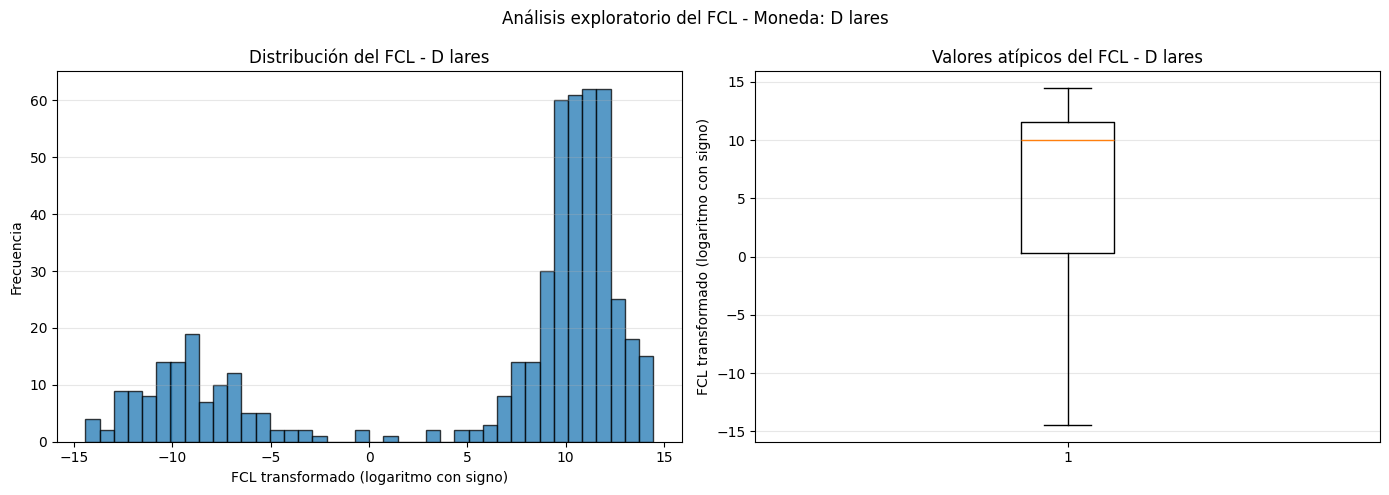

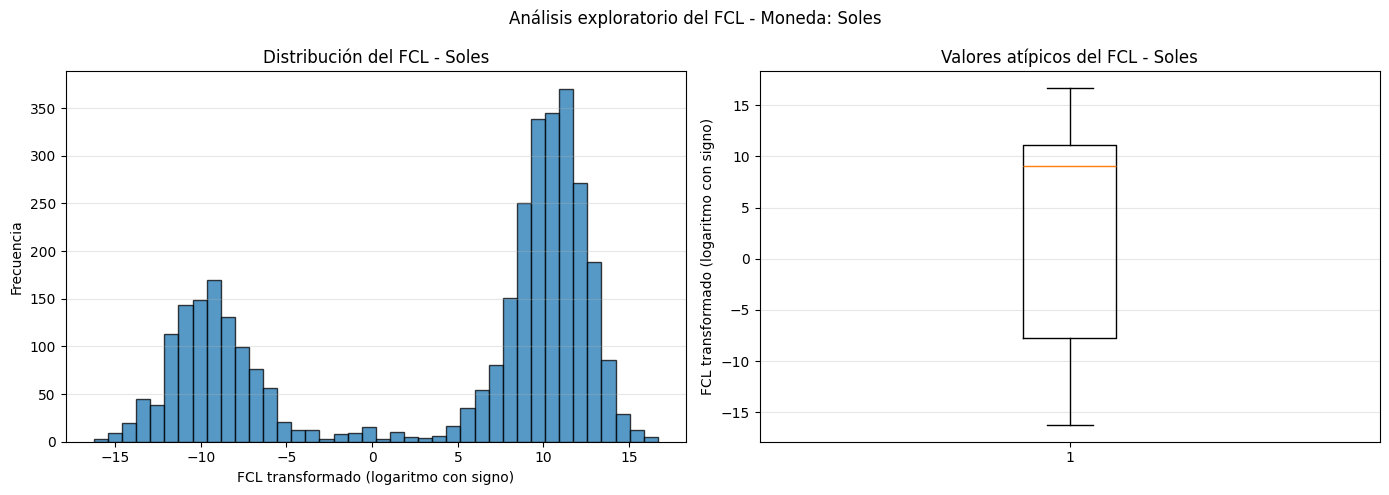

RESUMEN DE VALORES ATÍPICOS POR MONEDA


,Moneda,Observaciones,Valores_atipicos_IQR,Porcentaje_atipicos
0,D lares,506,77,15.22
1,Soles,3392,639,18.84


In [8]:
# ==========================================
# EDA - 5. DISTRIBUCIÓN Y VALORES ATÍPICOS
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_fcl = df.dropna(subset=["FCL_preliminar"]).copy()

# Transformación logarítmica con signo:
# permite visualizar valores positivos y negativos
df_fcl["FCL_log_signo"] = (
    np.sign(df_fcl["FCL_preliminar"])
    * np.log1p(np.abs(df_fcl["FCL_preliminar"]))
)

# Analizar cada moneda por separado
for moneda, datos in df_fcl.groupby("Moneda"):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    axes[0].hist(
        datos["FCL_log_signo"],
        bins=40,
        edgecolor="black",
        alpha=0.75
    )

    axes[0].set_title(f"Distribución del FCL - {moneda}")
    axes[0].set_xlabel("FCL transformado (logaritmo con signo)")
    axes[0].set_ylabel("Frecuencia")
    axes[0].grid(axis="y", alpha=0.3)

    # Diagrama de caja
    axes[1].boxplot(
        datos["FCL_log_signo"].dropna(),
        vert=True
    )

    axes[1].set_title(f"Valores atípicos del FCL - {moneda}")
    axes[1].set_ylabel("FCL transformado (logaritmo con signo)")
    axes[1].grid(axis="y", alpha=0.3)

    plt.suptitle(
        f"Análisis exploratorio del FCL - Moneda: {moneda}"
    )

    plt.tight_layout()
    plt.show()

# Detección de valores atípicos mediante IQR
resultados = []

for moneda, datos in df_fcl.groupby("Moneda"):

    q1 = datos["FCL_preliminar"].quantile(0.25)
    q3 = datos["FCL_preliminar"].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    atipicos = (
        (datos["FCL_preliminar"] < limite_inferior)
        | (datos["FCL_preliminar"] > limite_superior)
    ).sum()

    resultados.append({
        "Moneda": moneda,
        "Observaciones": len(datos),
        "Valores_atipicos_IQR": atipicos,
        "Porcentaje_atipicos": round(
            atipicos / len(datos) * 100, 2
        )
    })

print("RESUMEN DE VALORES ATÍPICOS POR MONEDA")
display(pd.DataFrame(resultados))

SECTORES ECONÓMICOS IDENTIFICADOS


,Observaciones
TipoSector,
DIVERSOS,1066
INDUSTRIALES,835
SERVICIOS PUBLICOS,475
MINERAS,389
SEGUROS,323
AGRICOLAS,271
BANCOS,260
FINANCIERAS,188
A.F.P.,85



ESTADÍSTICAS SECTORIALES


,Moneda,TipoSector,Observaciones,Empresas,FCL_mediana,FCL_media,FCL_minimo,FCL_maximo
0,D lares,AGRICOLAS,3,2,-472.0,19989.67,-2008.0,62449.0
1,D lares,DIVERSOS,93,16,8597.0,31329.14,-57409.0,311400.0
2,D lares,INDUSTRIALES,106,11,6088.5,-23449.66,-1668126.0,343945.0
3,D lares,MINERAS,219,18,43819.0,178227.16,-1858184.0,1909766.0
4,D lares,SERVICIOS PUBLICOS,85,9,43969.0,63427.89,-162409.0,356974.0
5,Soles,A.F.P.,85,6,102031.0,88268.33,-121792.0,193800.0
6,Soles,AGRICOLAS,268,16,1166.5,13697.84,-50819.0,183974.0
7,Soles,BANCOS,260,24,26827.5,355933.39,-11333370.0,17466182.0
8,Soles,DIVERSOS,973,103,2264.0,12846.84,-7639533.0,801402.0
9,Soles,FINANCIERAS,188,19,-3165.0,-25271.77,-1919876.0,1337516.0


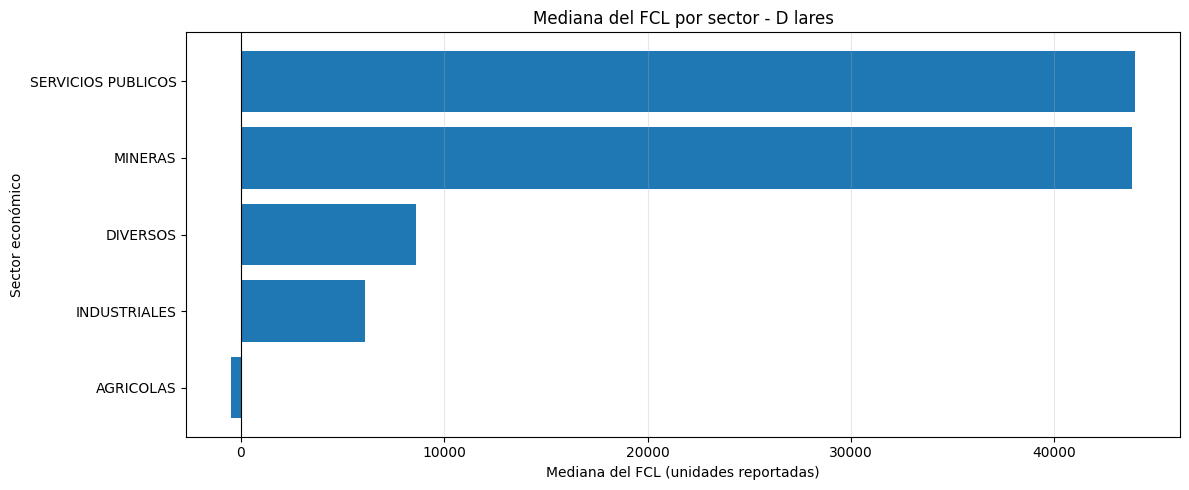

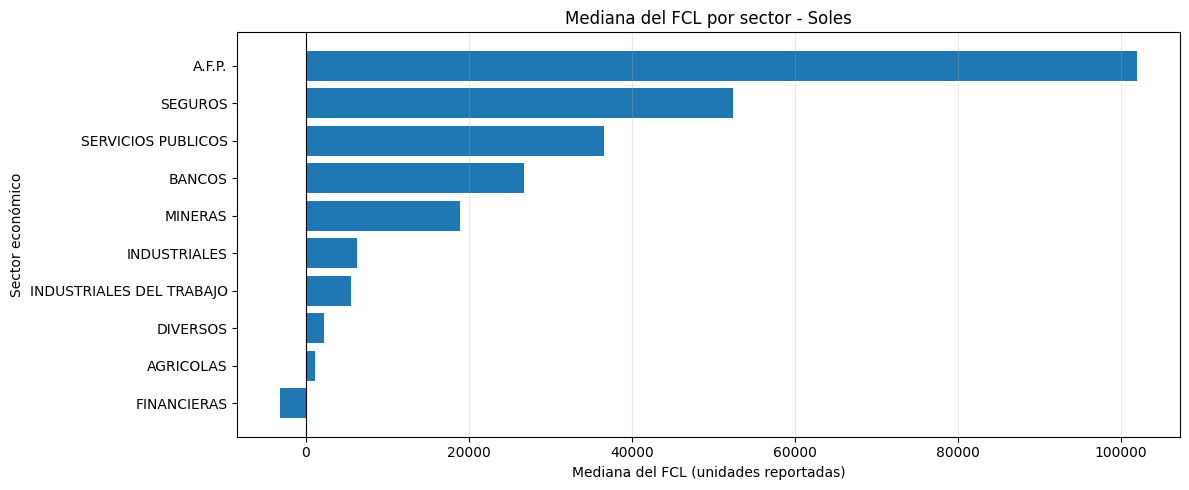

Análisis sectorial completado.


In [9]:
# ==========================================
# EDA - 6. ANÁLISIS SECTORIAL DEL FCL
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

df_fcl = df.dropna(subset=["FCL_preliminar"]).copy()

# Comprobar los sectores disponibles
print("SECTORES ECONÓMICOS IDENTIFICADOS")
display(
    df_fcl["TipoSector"]
    .value_counts(dropna=False)
    .to_frame(name="Observaciones")
)

# Estadísticas del FCL por sector y moneda
resumen_sectorial = (
    df_fcl.groupby(
        ["Moneda", "TipoSector"],
        dropna=False
    )
    .agg(
        Observaciones=("FCL_preliminar", "count"),
        Empresas=("RPJ", "nunique"),
        FCL_mediana=("FCL_preliminar", "median"),
        FCL_media=("FCL_preliminar", "mean"),
        FCL_minimo=("FCL_preliminar", "min"),
        FCL_maximo=("FCL_preliminar", "max")
    )
    .reset_index()
)

print("\nESTADÍSTICAS SECTORIALES")
display(resumen_sectorial.round(2))

# Gráficos separados por moneda
for moneda, datos in resumen_sectorial.groupby("Moneda"):

    datos = datos.sort_values("FCL_mediana")

    plt.figure(figsize=(12, max(5, len(datos) * 0.5)))

    plt.barh(
        datos["TipoSector"].fillna("Sin sector").astype(str),
        datos["FCL_mediana"]
    )

    plt.title(f"Mediana del FCL por sector - {moneda}")
    plt.xlabel("Mediana del FCL (unidades reportadas)")
    plt.ylabel("Sector económico")
    plt.axvline(0, color="black", linewidth=0.8)
    plt.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Análisis sectorial completado.")

Variables disponibles: ['ActivoTotal', 'PasivoTotal', 'PatrimonioTotal', 'TotalIngreso', 'UtilidadNeta', 'FCO', 'CAPEX_reportado', 'FCL_preliminar']

MATRIZ DE CORRELACIONES - D lares


,ActivoTotal,PasivoTotal,PatrimonioTotal,TotalIngreso,UtilidadNeta,FCO,CAPEX_reportado,FCL_preliminar
ActivoTotal,1.000,0.931,0.954,0.865,0.548,0.700,-0.748,0.478
PasivoTotal,0.931,1.000,0.818,0.839,0.470,0.638,-0.702,0.432
PatrimonioTotal,0.954,0.818,1.000,0.842,0.589,0.707,-0.763,0.489
TotalIngreso,0.865,0.839,0.842,1.000,0.616,0.729,-0.805,0.505
UtilidadNeta,0.548,0.470,0.589,0.616,1.000,0.716,-0.487,0.620
FCO,0.700,0.638,0.707,0.729,0.716,1.000,-0.648,0.837
CAPEX_reportado,-0.748,-0.702,-0.763,-0.805,-0.487,-0.648,1.000,-0.326
FCL_preliminar,0.478,0.432,0.489,0.505,0.620,0.837,-0.326,1.000


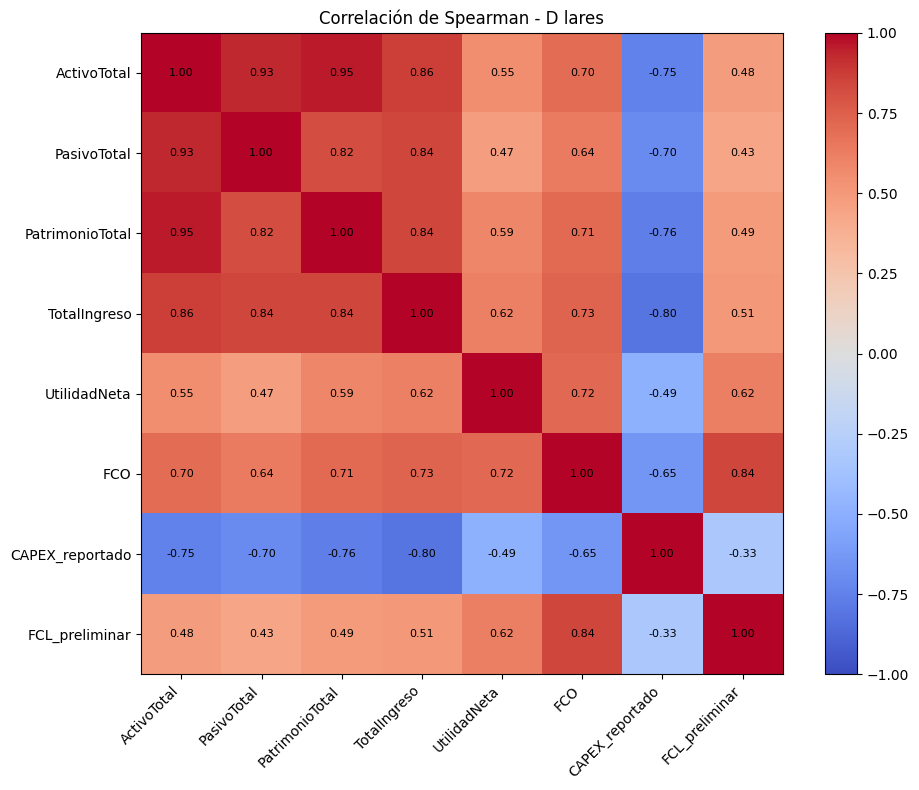


MATRIZ DE CORRELACIONES - Soles


,ActivoTotal,PasivoTotal,PatrimonioTotal,TotalIngreso,UtilidadNeta,FCO,CAPEX_reportado,FCL_preliminar
ActivoTotal,1.000,0.921,0.908,0.740,0.676,0.486,-0.571,0.347
PasivoTotal,0.921,1.000,0.722,0.772,0.561,0.449,-0.605,0.304
PatrimonioTotal,0.908,0.722,1.000,0.684,0.720,0.489,-0.547,0.361
TotalIngreso,0.740,0.772,0.684,1.000,0.638,0.566,-0.786,0.394
UtilidadNeta,0.676,0.561,0.720,0.638,1.000,0.543,-0.468,0.465
FCO,0.486,0.449,0.489,0.566,0.543,1.000,-0.473,0.895
CAPEX_reportado,-0.571,-0.605,-0.547,-0.786,-0.468,-0.473,1.000,-0.226
FCL_preliminar,0.347,0.304,0.361,0.394,0.465,0.895,-0.226,1.000


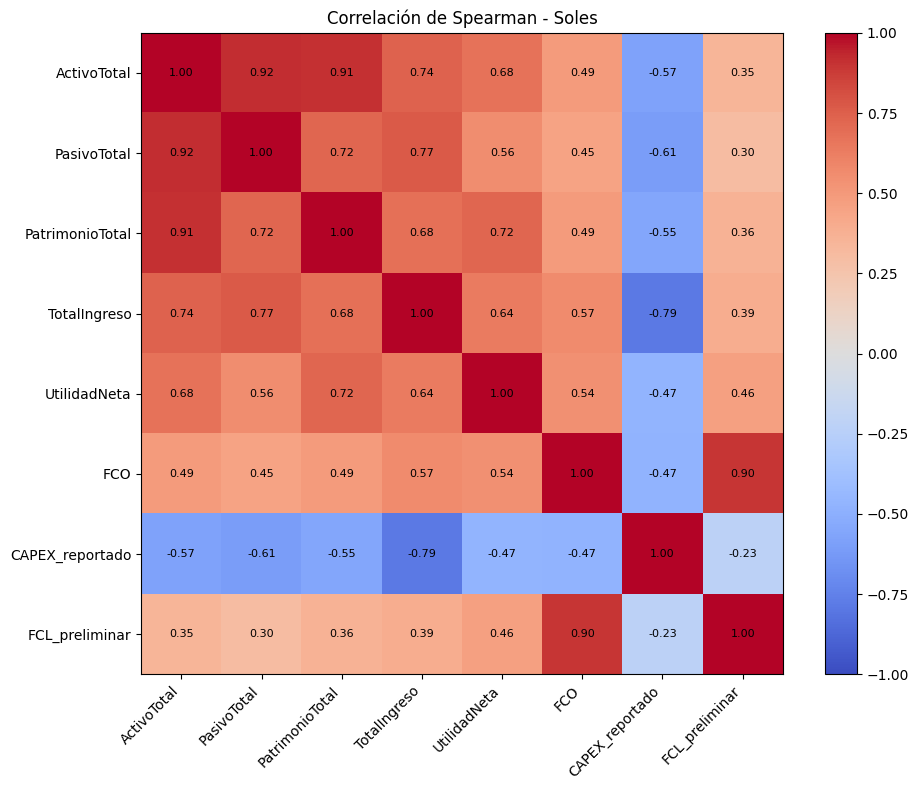

In [10]:
# ==========================================
# EDA - 7. MATRIZ DE CORRELACIONES
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

variables = [
    "ActivoTotal",
    "PasivoTotal",
    "PatrimonioTotal",
    "TotalIngreso",
    "UtilidadNeta",
    "FCO",
    "CAPEX_reportado",
    "FCL_preliminar"
]

# Verificar qué variables existen
variables_disponibles = [
    v for v in variables if v in df.columns
]

print("Variables disponibles:", variables_disponibles)

# Correlaciones por moneda
for moneda, datos in df.groupby("Moneda"):

    datos_numericos = datos[variables_disponibles].apply(
        pd.to_numeric, errors="coerce"
    )

    correlacion = datos_numericos.corr(method="spearman")

    print(f"\nMATRIZ DE CORRELACIONES - {moneda}")
    display(correlacion.round(3))

    fig, ax = plt.subplots(figsize=(10, 8))

    imagen = ax.imshow(
        correlacion,
        cmap="coolwarm",
        vmin=-1,
        vmax=1
    )

    ax.set_xticks(range(len(correlacion.columns)))
    ax.set_yticks(range(len(correlacion.index)))

    ax.set_xticklabels(
        correlacion.columns,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(correlacion.index)

    for i in range(len(correlacion.index)):
        for j in range(len(correlacion.columns)):
            valor = correlacion.iloc[i, j]
            if pd.notna(valor):
                ax.text(
                    j, i, f"{valor:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8
                )

    plt.colorbar(imagen, ax=ax)
    plt.title(f"Correlación de Spearman - {moneda}")
    plt.tight_layout()
    plt.show()